# IE Tower VPR — test the trained model

**Goal.** Given a photo of an indoor location somewhere in the IE Tower (above-ground floor or basement level), retrieve the most similar gallery frames and predict which floor the photo was taken on.

## Before running this notebook

Make sure the pipeline has been built once on your machine:

```bash
pip install -r requirements.txt
python scripts/sync_drive_data.py             # pull all team videos
python scripts/extract_frames_and_update_csv.py
python scripts/assign_splits.py
python scripts/run_pipeline.py --model-name dinov2_vits14_hires   # best config
python scripts/run_evaluation.py
```

After that, the four files this notebook needs are on disk:

* `outputs/index/gallery.index` — FAISS Flat-IP index over the gallery embeddings.
* `outputs/embeddings/gallery_metadata.csv` — one row per indexed frame (image_path, label, split, …).
* `outputs/embeddings/gallery_info.json` — side-car file recording which backbone produced the embeddings (used here to load the matching feature extractor automatically).
* `outputs/results/evaluation.json` — Top-K accuracy and mAP for the held-out queries.

## What this notebook does

1. Loads the FAISS index, gallery metadata and the matching feature extractor.
2. Reports the saved evaluation metrics so you can see how well the model performs before testing on your own photo.
3. Picks a random held-out query frame and shows the prediction with Top-K matches (sanity check that the pipeline is wired up correctly).
4. Lets you point at any image on disk to test the model on a fresh photo.

## How the model works

* **Feature extractor.** By default DINOv2 ViT-S/14 at its native 518×518 resolution (Meta AI, self-supervised on 142 M images), frozen. This is a drop-in upgrade from the original ResNet50 baseline — see `outputs/_compare/comparison.json` for the bake-off results.
* **Gallery.** Every frame whose `split == "gallery"` in `data/metadata/dataset.csv`, encoded with the feature extractor and stored in a FAISS Flat-IP index. L2-normalised embeddings are searched via cosine similarity.
* **Prediction.** Top-K cosine search, then majority vote over the floor labels of those K matches. Confidence is the size of the winning vote (e.g. `4/5` means 4 of the 5 nearest neighbours agree).

Every backbone described in the README is supported automatically — the notebook reads `gallery_info.json` to pick the matching feature extractor for whatever index is currently on disk.

In [1]:
# Cell 1 — Imports and project-path setup
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Walk up from notebooks/ to the repo root so `src` is importable.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.features.extract_embeddings import extract_pil_image_embedding
from src.features.models import get_feature_extractor, resolve_device
from src.features.transforms import get_image_transform
from src.retrieval.faiss_utils import load_index
from src.retrieval.search import search_index
from src.utils.config import EMBEDDINGS_DIR, INDEX_DIR, RESULTS_DIR

print(f"Repo root:   {REPO_ROOT}")
print(f"Embeddings:  {EMBEDDINGS_DIR}")
print(f"Index:       {INDEX_DIR}")
print(f"Eval JSON:   {RESULTS_DIR}")

Repo root:   C:\Users\Juan Sebastian Peña\Desktop\IEUniversity\ComputerVision\ie-tower-visual-place-recognition
Embeddings:  C:\Users\Juan Sebastian Peña\Desktop\IEUniversity\ComputerVision\ie-tower-visual-place-recognition\outputs\embeddings
Index:       C:\Users\Juan Sebastian Peña\Desktop\IEUniversity\ComputerVision\ie-tower-visual-place-recognition\outputs\index
Eval JSON:   C:\Users\Juan Sebastian Peña\Desktop\IEUniversity\ComputerVision\ie-tower-visual-place-recognition\outputs\results


In [2]:
# Cell 2 — Load the saved gallery + the matching feature extractor.
INDEX_PATH = INDEX_DIR / "gallery.index"
METADATA_PATH = EMBEDDINGS_DIR / "gallery_metadata.csv"
INFO_PATH = EMBEDDINGS_DIR / "gallery_info.json"
EVAL_PATH = RESULTS_DIR / "evaluation.json"

for path in (INDEX_PATH, METADATA_PATH):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing artifact: {path}.\n"
            "Run `python scripts/run_pipeline.py` and `python scripts/run_evaluation.py` first."
        )

info = json.loads(INFO_PATH.read_text(encoding="utf-8")) if INFO_PATH.exists() else {}
model_name = info.get("model_name", "resnet50")
print(f"Backbone in use:  {model_name}")
if info:
    print(f"Embedding dim:    {info.get('embedding_dim')}")
    print(f"Metric:           {info.get('metric', 'cosine')}")
    print(f"Gallery rows:     {info.get('num_rows')}")

device = resolve_device(None)
model, embedding_dim = get_feature_extractor(model_name)
transform = get_image_transform(model_name)

index = load_index(INDEX_PATH)
metadata = pd.read_csv(METADATA_PATH)

print()
print(f"Device:           {device}")
print(f"Floors covered:   {sorted(metadata['label'].unique())}")
print(f"Gallery rows:     {len(metadata)}")

Backbone in use:  dinov2_vits14_hires
Embedding dim:    384
Metric:           cosine
Gallery rows:     2877


C:\Users\Juan Sebastian Peña/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Juan Sebastian Peña/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Juan Sebastian Peña/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")



Device:           cpu
Floors covered:   ['basement0', 'basement2', 'basement3', 'basement4', 'floor10', 'floor11', 'floor12', 'floor13', 'floor14', 'floor15', 'floor16', 'floor17', 'floor18', 'floor19', 'floor20', 'floor21', 'floor22', 'floor23', 'floor3', 'floor4', 'floor5', 'floor6', 'floor7', 'floor8', 'floor9']
Gallery rows:     2877


In [3]:
# Cell 3 — Show the evaluation metrics saved by run_evaluation.py.
if EVAL_PATH.exists():
    eval_results = json.loads(EVAL_PATH.read_text(encoding="utf-8"))
    print("Headline metrics:")
    print(f"  Top-1 accuracy: {eval_results.get('top_1_accuracy', 0):.1%}")
    print(f"  Top-5 accuracy: {eval_results.get('top_5_accuracy', 0):.1%}")
    print(f"  mAP:            {eval_results.get('mAP', 0):.1%}")
    print(f"  Held-out queries: {eval_results.get('num_queries', 'unknown')}")

    per_class = eval_results.get("per_class") or {}
    if per_class:
        print()
        print("Per-class Top-1 accuracy (sorted by floor):")
        def _key(label):
            text = str(label)
            if text.startswith("basement"):
                try:
                    return (0, int(text.replace("basement", "")))
                except ValueError:
                    return (0, 0)
            if text.startswith("floor"):
                try:
                    return (1, int(text.replace("floor", "")))
                except ValueError:
                    return (1, 0)
            return (2, 0)
        for label in sorted(per_class.keys(), key=_key):
            acc = per_class[label]["top1_accuracy"]
            n = per_class[label]["queries"]
            bar = "#" * int(round(acc * 30))
            print(f"  {label:12s}  {acc:6.1%}  ({n:3d} queries)  {bar}")
else:
    print("No evaluation.json yet. Run `python scripts/run_evaluation.py` and re-run this cell.")

Headline metrics:
  Top-1 accuracy: 52.8%
  Top-5 accuracy: 72.0%
  mAP:            57.7%
  Held-out queries: 504

Per-class Top-1 accuracy (sorted by floor):
  basement0      76.9%  ( 13 queries)  #######################
  basement2      81.0%  ( 21 queries)  ########################
  basement3      86.7%  ( 15 queries)  ##########################
  basement4      78.6%  ( 28 queries)  ########################
  floor3         63.2%  ( 19 queries)  ###################
  floor4         40.7%  ( 27 queries)  ############
  floor5         40.0%  ( 15 queries)  ############
  floor6         47.6%  ( 21 queries)  ##############
  floor7         53.8%  ( 13 queries)  ################
  floor8         38.5%  ( 13 queries)  ############
  floor9         51.9%  ( 27 queries)  ################
  floor10        48.4%  ( 31 queries)  ###############
  floor11        47.8%  ( 23 queries)  ##############
  floor12        55.0%  ( 20 queries)  ################
  floor13        54.5%  ( 22 queries) 

In [4]:
# Cell 4 — Helper functions for running and visualising a query.
from src.retrieval.hierarchical import (
    DEFAULT_CONFIDENCE_THRESHOLD,
    explain_prediction,
    hierarchical_predict,
)


def predict_floor(image_path, top_k=5, metric="cosine"):
    """Run a single retrieval query.

    Returns ``(predicted_label, votes, results)`` where ``results`` is a list
    of ``SearchResult`` objects with ``rank``, ``score``, ``label``,
    ``area``, ``section``, ``floor_range`` and ``image_path`` attributes.
    """
    image_path = Path(image_path)
    if not image_path.exists():
        raise FileNotFoundError(image_path)

    image = ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")

    embedding = extract_pil_image_embedding(
        image=image,
        model=model,
        transform=transform,
        device=device,
        normalize=metric == "cosine",
    )
    results = search_index(
        query_embeddings=embedding,
        index=index,
        metadata=metadata,
        top_k=top_k,
        metric=metric,
    )[0]

    if not results:
        return None, 0, []
    counts = Counter(r.label for r in results if r.label)
    top_label, top_count = counts.most_common(1)[0]
    return top_label, top_count, results


def predict_hierarchy(image_path, top_k=5, threshold=DEFAULT_CONFIDENCE_THRESHOLD):
    """Wrap predict_floor and run the four-tier hierarchical predictor.

    Returns ``(prediction_dict, results)`` where prediction_dict has the
    keys ``best``, ``selected_level``, ``fallback_chain`` and
    ``threshold`` (see ``src/retrieval/hierarchical.py`` for details).
    """
    _, _, results = predict_floor(image_path, top_k=top_k)
    return hierarchical_predict(results, threshold=threshold), results


def show_results(query_path, top_k=5, ground_truth=None):
    """Run a query and render the prediction + Top-K thumbnails inline."""
    prediction, results = predict_hierarchy(query_path, top_k=top_k)
    confidence_line = explain_prediction(prediction)
    if ground_truth is not None and prediction.get("best"):
        best = prediction["best"]
        verdict = "✓ correct" if best.get("label") == ground_truth else f"✗ wrong (true: {ground_truth})"
        confidence_line = f"{confidence_line}  —  {verdict}"
    print(confidence_line)
    print()
    print("Fallback chain (most-specific first):")
    for entry in prediction.get("fallback_chain", []):
        marker = "  *" if entry["level"] == prediction.get("selected_level") else "   "
        print(f"{marker} {entry['human_level']:14s}  {str(entry['label']):20s}  {entry['votes']}/{entry['k']}  ({entry['ratio']:.0%})")
    print()

    fig, axes = plt.subplots(1, len(results) + 1, figsize=(3 * (len(results) + 1), 3))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    query_img = ImageOps.exif_transpose(Image.open(query_path)).convert("RGB")
    axes[0].imshow(query_img)
    axes[0].set_title("Query")
    axes[0].axis("off")

    for ax, result in zip(axes[1:], results):
        try:
            img = Image.open(result.image_path).convert("RGB")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "missing", ha="center", va="center")
        title = f"#{result.rank} {result.label}" + chr(10) + f"score {result.score:.3f}"
        if ground_truth is not None:
            title += "  ✓" if result.label == ground_truth else "  ✗"
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return prediction, results

In [5]:
# Cell 4b — OCR helper (read floor numbers from the photo when visible).
from src.features.ocr_predictor import OCRFloorPredictor

ocr_predictor = OCRFloorPredictor(
    known_labels=set(metadata["label"].astype(str).unique()),
    confidence_threshold=0.6,
)


def predict_with_ocr(image_path, top_k=5):
    """Run OCR + retrieval. If OCR confidently reads a known floor
    label, the result snaps to that floor regardless of the
    retrieval prediction. Returns (final_label, ocr_result, retrieval_results).
    """
    image = ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    ocr_pred = ocr_predictor.predict(image)
    _, _, retrieval_results = predict_floor(image_path, top_k=top_k)
    if ocr_pred.label is not None and ocr_pred.confidence >= 0.6:
        final = ocr_pred.label
    else:
        prediction = hierarchical_predict(retrieval_results)
        final = (prediction.get("best") or {}).get("label")
    return final, ocr_pred, retrieval_results


# Quick OCR smoke test on a known frame. The model needs ~1 minute the
# first time to download EasyOCR weights into ~/.EasyOCR/.
_sample_path = REPO_ROOT / "data" / "processed_frames" / "floor10" / "f10_central_main_frame_000001.jpg"
if _sample_path.exists():
    final, ocr_pred, _ = predict_with_ocr(_sample_path)
    print(f"final label: {final}")
    print(f"OCR available: {ocr_pred.available}")
    print(f"OCR label:     {ocr_pred.label}  (confidence {ocr_pred.confidence:.2f})")
    print(f"OCR detections (raw text):")
    for det in ocr_pred.detections[:6]:
        print(f"  - {det.raw_text!r:25s} conf {det.confidence:.2f}  -> {det.text or '(no map)'}")
else:
    print("sample frame not on disk — skipping OCR smoke test")

C:\Users\Juan Sebastian Peña\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


final label: floor10
OCR available: True
OCR label:     None  (confidence 0.00)
OCR detections (raw text):
  - 'W'                       conf 0.35  -> (no map)


## Sanity check: random held-out query

We pick a random row whose `split == "query"` and ask the model to retrieve the closest gallery matches. Because every query frame was held out of the gallery (`scripts/assign_splits.py`), this is a real retrieval and not a self-match.

Ground-truth floor: floor14
Query image:        C:\Users\Juan Sebastian Peña\Desktop\IEUniversity\ComputerVision\ie-tower-visual-place-recognition\data\processed_frames\floor14\f14_elevator_main_frame_000006.jpg


Section: above-ground (5/5 = 100%). Model confident only about above-ground vs basement.  ·  Looks like a elevator (100% of matches).  —  ✗ wrong (true: floor14)

Fallback chain (most-specific first):
    exact floor     floor14               1/5  (20%)
    floor range     midrise               2/5  (40%)
  * section         above-ground          5/5  (100%)



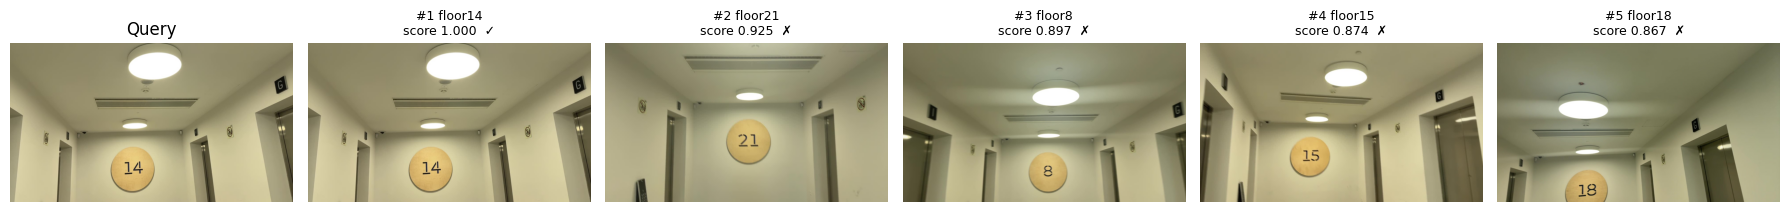

In [6]:
# Cell 5 — Pick a random held-out query and run the model on it.
csv_path = REPO_ROOT / "data" / "metadata" / "dataset.csv"
all_rows = pd.read_csv(csv_path)
query_rows = all_rows[all_rows["split"] == "query"]

if query_rows.empty:
    raise RuntimeError("No query rows in dataset.csv. Did you run assign_splits.py?")

sample = query_rows.sample(1, random_state=42).iloc[0]
sample_path = REPO_ROOT / sample["image_path"]
if not sample_path.exists():
    sample_path = REPO_ROOT / "data" / sample["image_path"]

print(f"Ground-truth floor: {sample['label']}")
print(f"Query image:        {sample_path}")
_ = show_results(sample_path, top_k=5, ground_truth=str(sample["label"]))

## Test with your own image

Drop any photo of an IE Tower indoor location somewhere on disk and put the path in the cell below. JPG and PNG both work. Phone photos are handled correctly — EXIF orientation is baked into the pixels before the model sees the image, so portrait shots are not classified upside down.

Floor: floor3 (3/5 = 60%, exact)  ·  Looks like a hallway (100% of matches).

Fallback chain (most-specific first):
  * exact floor     floor3                3/5  (60%)
    floor range     lowrise               5/5  (100%)
    section         above-ground          5/5  (100%)



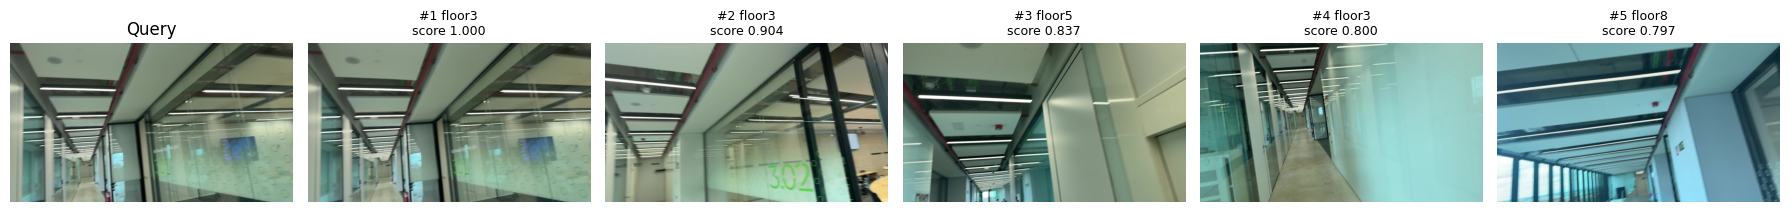

In [7]:
# Cell 6 — Edit the path below and re-run this cell to test your own image.
your_image = REPO_ROOT / "data" / "processed_frames" / "floor3" / "f03_hallway_main_frame_000010.jpg"

# Replace the line above with your own absolute or relative path, e.g.:
# your_image = Path(r"C:\Users\Professor\Desktop\my_photo.jpg")
# your_image = Path("/Users/professor/Desktop/my_photo.jpg")

_ = show_results(your_image, top_k=5)

## How to read the output

The prediction is composed of three signals:

1. **Spatial fallback chain** (floor → floor_range → section). The model picks the most specific tier whose Top-K vote ratio meets the configured confidence threshold (default 0.6 = 3/5). Lower tiers are still printed so you can see what the model would have answered at each level.
2. **Area tag** (orthogonal). The vote-winner from the `area` column — `hallway`, `elevator`, `stairs`, `classroom`, `chill_lounge`, etc. Always shown alongside the spatial tier so you know what kind of space the model thinks the photo is.
3. **OCR override** (optional). When `predict_with_ocr` is used and EasyOCR confidently reads a floor number, the final label snaps to that floor regardless of retrieval. This targets the vertical-confusion failure mode directly: if the photo shows the floor plaque, we should just trust it.

Read the printed lines as:

* **Score** — inner product (cosine similarity for L2-normalised embeddings). Higher is closer; >0.85 is a very strong visual match in this dataset.
* **Ground truth** (only shown for the random sanity-check sample) — the true label according to the dataset CSV. The notebook colour-codes whether each Top-K match is correct (`✓`) or not (`✗`).

## Known failure modes

Documented in detail in the README's "Analysis: why isn't accuracy higher?" section. The two most common ones:

1. **Vertical confusion.** The IE Tower hallways and elevators repeat the same layout from one above-ground floor to the next. The hierarchical predictor catches this case explicitly: when the floor tier fails, it falls back to floor_range or section so the user still gets a useful answer. OCR (when enabled) can short-circuit this whenever a number is visible.
2. **Lighting / device shift.** All gallery frames came from a single phone walkthrough per area at one moment in time. Photos taken under very different lighting or with a different camera tend to drop in confidence — likely surfacing as a step-down to floor_range.

Triplet-loss fine-tuning (PR-C in the next-iteration roadmap) is expected to lift the floor-tier resolution rate without touching the fallback machinery.